# 04 — EDA: Radiomic Features

Exploratory data analysis of the pyradiomics feature matrix extracted from ISIC images using Mask R-CNN segmentation masks.

**Source:** `data/features_features_all_channels.csv` (~500 MB, ~70k images)  
**Feature structure:** `{channel}__original_{class}_{feature}` across 4 channels (blue, green, red, gray)  
**Feature classes:** firstorder · glcm · gldm · glrlm · glszm · ngtdm · shape2D

---

## 0. Setup

In [66]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import warnings
warnings.filterwarnings("ignore")

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

from src.paths import DATA_DIR, RESULTS_DIR, PROCESSED_DIR, ensure_dir
from src.viz import setup_style, save_fig, CLASS_COLORS

setup_style()

FEATURES_CSV  = DATA_DIR / "features_features_all_channels.csv"
METADATA_PATH = PROCESSED_DIR / "isic_selected.parquet"
OUT_DIR       = ensure_dir(RESULTS_DIR / "eda" / "features")

CHANNELS      = ["blue", "green", "red", "gray"]
FEATURE_CLASSES = ["firstorder", "glcm", "gldm", "glrlm", "glszm", "ngtdm", "shape2D"]
CHANNEL_COLORS  = {"blue": "#2196F3", "green": "#4CAF50", "red": "#F44336", "gray": "#9E9E9E"}

print(f"Features CSV : {FEATURES_CSV}")
print(f"Metadata     : {METADATA_PATH}")
print(f"Output dir   : {OUT_DIR}")

Features CSV : /Users/indalecio.rios/Documents/personal-github/scd-ml/data/features_features_all_channels.csv
Metadata     : /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/isic_selected.parquet
Output dir   : /Users/indalecio.rios/Documents/personal-github/scd-ml/results/eda/features


---
## 1. Data Loading & Schema

In [67]:
print("Loading features CSV with Polars...")
df = pl.read_csv(FEATURES_CSV, infer_schema_length=10_000, null_values=["nan", "inf", "-inf"])

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory (est.)  : {df.estimated_size('mb'):.1f} MB")
print()

dtype_counts = df.dtypes
n_float = sum(1 for d in dtype_counts if d in (pl.Float32, pl.Float64))
n_str   = sum(1 for d in dtype_counts if d == pl.Utf8)
n_int   = sum(1 for d in dtype_counts if d in (pl.Int32, pl.Int64, pl.Int8, pl.Int16))
print(f"Float columns  : {n_float:,}")
print(f"String columns : {n_str}")
print(f"Int columns    : {n_int}")

Loading features CSV with Polars...
Shape          : 76,715 rows × 409 columns
Memory (est.)  : 239.7 MB

Float columns  : 408
String columns : 1
Int columns    : 0


In [68]:
# Preview — transpose so we can read long column names
print("First 5 rows (first 8 columns):")
df.head(5).select(df.columns[:8])

First 5 rows (first 8 columns):


image_id,blue__original_shape2D_Elongation,blue__original_shape2D_MajorAxisLength,blue__original_shape2D_MaximumDiameter,blue__original_shape2D_MeshSurface,blue__original_shape2D_MinorAxisLength,blue__original_shape2D_Perimeter,blue__original_shape2D_PerimeterSurfaceRatio
str,f64,f64,f64,f64,f64,f64,f64
"""ISIC_0000012""",0.779893,272.659195,271.088546,45323.5,212.645035,815.536147,0.017994
"""ISIC_0000013""",0.710941,612.046097,607.173781,207856.5,435.12852,1783.481456,0.00858
"""ISIC_0000014""",0.596709,743.950042,742.822321,258635.5,443.921484,2029.505843,0.007847
"""ISIC_0000015""",0.937082,496.045041,511.038159,179312.5,464.834667,1635.817459,0.009123
"""ISIC_0000004""",0.823181,688.422067,689.823891,303751.5,566.696279,2133.942351,0.007025


---
## 2. Column Taxonomy

Parse `{channel}__original_{class}_{feature}` into structured metadata.

In [69]:
feature_cols = [c for c in df.columns if "__" in c]
id_cols      = [c for c in df.columns if "__" not in c]

print(f"ID / index columns : {id_cols}")
print(f"Feature columns    : {len(feature_cols):,}")

def parse_col(col: str) -> dict:
    channel, rest = col.split("__", 1)               # blue, original_glcm_Contrast
    parts = rest.replace("original_", "").split("_", 1)  # [glcm, Contrast]
    feat_class = parts[0] if len(parts) > 0 else "unknown"
    feat_name  = parts[1] if len(parts) > 1 else ""
    return {"column": col, "channel": channel, "class": feat_class, "feature": feat_name}

taxonomy = pd.DataFrame([parse_col(c) for c in feature_cols])

print("\nTaxonomy summary:")
print(taxonomy.groupby(["channel", "class"]).size().unstack(fill_value=0))

ID / index columns : ['image_id']
Feature columns    : 408

Taxonomy summary:
class    firstorder  glcm  gldm  glrlm  glszm  ngtdm  shape2D
channel                                                      
blue             18    24    14     16     16      5        9
gray             18    24    14     16     16      5        9
green            18    24    14     16     16      5        9
red              18    24    14     16     16      5        9


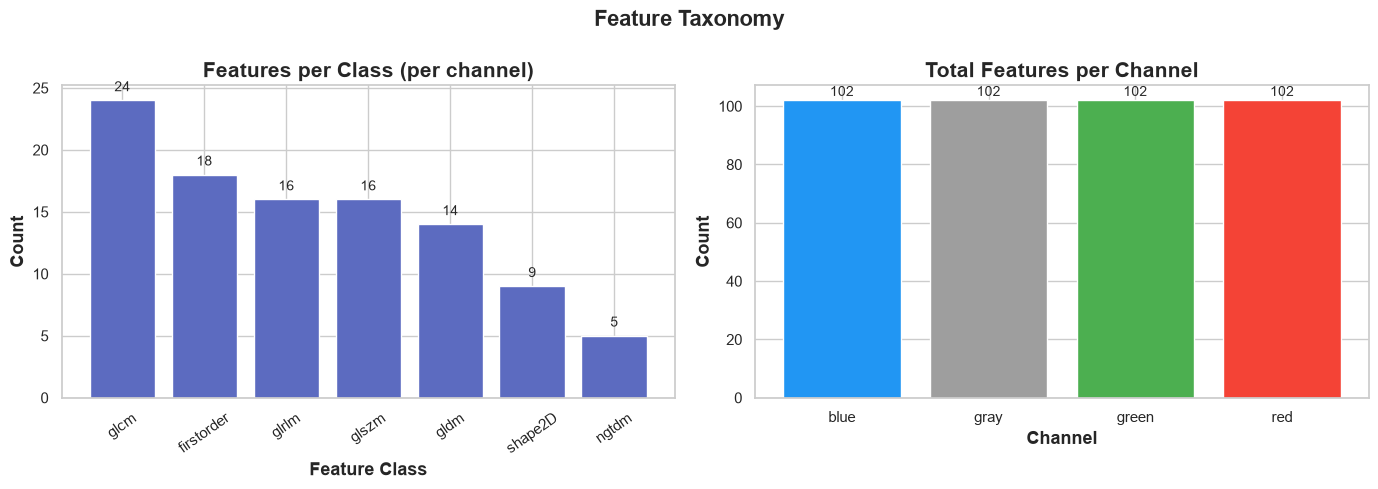

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Features per class (one channel only, should be symmetric)
per_class = taxonomy[taxonomy["channel"] == "blue"].groupby("class").size().sort_values(ascending=False)
axes[0].bar(per_class.index, per_class.values, color="#5C6BC0")
axes[0].set_title("Features per Class (per channel)")
axes[0].set_xlabel("Feature Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)
for bar, val in zip(axes[0].patches, per_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                 ha="center", va="bottom", fontsize=10)

# Features per channel
per_channel = taxonomy.groupby("channel").size()
colors = [CHANNEL_COLORS[c] for c in per_channel.index]
axes[1].bar(per_channel.index, per_channel.values, color=colors)
axes[1].set_title("Total Features per Channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Count")
for bar, val in zip(axes[1].patches, per_channel.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                 ha="center", va="bottom", fontsize=10)

fig.suptitle("Feature Taxonomy")
plt.tight_layout()
save_fig(fig, OUT_DIR, "01_taxonomy")
plt.show()

In [71]:
# Verify symmetry: every feature exists in all 4 channels
pivot = taxonomy.groupby(["channel", "class"]).size().unstack(fill_value=0)
is_symmetric = (pivot.nunique(axis=0) == 1).all()
print(f"Symmetric across channels: {is_symmetric}")
if not is_symmetric:
    print("Asymmetric classes:")
    print(pivot.loc[:, pivot.nunique(axis=0) > 1])

Symmetric across channels: True


---
## 3. Data Quality

Assess readiness for ML: nulls, infinities, zero-variance columns, duplicates.

In [72]:
n_rows = df.height

# 3.1 Nulls
null_counts = df.select(pl.all().null_count()).row(0)
null_series = pd.Series(dict(zip(df.columns, null_counts)))
null_pct    = null_series / n_rows * 100

cols_any_null  = (null_pct > 0).sum()
cols_high_null = (null_pct > 5).sum()
print(f"Columns with any nulls  : {cols_any_null} / {len(df.columns)}")
print(f"Columns with >5% nulls  : {cols_high_null}")
if cols_high_null > 0:
    print(null_pct[null_pct > 5].sort_values(ascending=False).head(20))

Columns with any nulls  : 0 / 409
Columns with >5% nulls  : 0


In [73]:
# 3.2 Infinities — re-read raw to catch inf values missed by null_values param
df_raw = pl.read_csv(FEATURES_CSV, infer_schema_length=10_000)

float_cols = [c for c in feature_cols if df_raw[c].dtype in (pl.Float32, pl.Float64)]
inf_counts = (
    df_raw.select([pl.col(c).is_infinite().sum().alias(c) for c in float_cols])
    .row(0)
)
inf_series = pd.Series(dict(zip(float_cols, inf_counts)))
cols_with_inf = (inf_series > 0).sum()
total_inf     = inf_series.sum()
print(f"Columns with ±inf values : {cols_with_inf}")
print(f"Total inf values         : {total_inf:,}")
if cols_with_inf > 0:
    print("\nTop offenders:")
    print(inf_series[inf_series > 0].sort_values(ascending=False).head(15))
del df_raw

Columns with ±inf values : 0
Total inf values         : 0


In [74]:
# 3.3 Zero-variance columns
std_vals  = df.select([pl.col(c).std().alias(c) for c in float_cols]).row(0)
std_series = pd.Series(dict(zip(float_cols, std_vals)))
zero_var_cols = std_series[std_series == 0].index.tolist()
print(f"Zero-variance columns : {len(zero_var_cols)}")
if zero_var_cols:
    print(zero_var_cols)

Zero-variance columns : 0


In [75]:
# 3.4 Duplicate image_ids
id_col = "image_id" if "image_id" in df.columns else df.columns[0]
n_unique = df[id_col].n_unique()
n_dupes  = n_rows - n_unique
print(f"Total rows      : {n_rows:,}")
print(f"Unique image_ids: {n_unique:,}")
print(f"Duplicates      : {n_dupes:,}")

Total rows      : 76,715
Unique image_ids: 76,715
Duplicates      : 0


In [76]:
# 3.5 Quality summary table
quality_summary = pd.DataFrame([
    {"Check": "Nulls (any)",       "Count": int(cols_any_null),  "Action": "Impute median"},
    {"Check": "Nulls (>5%)",       "Count": int(cols_high_null), "Action": "Drop or impute"},
    {"Check": "Infinite values",   "Count": int(cols_with_inf),  "Action": "Replace with NaN → impute"},
    {"Check": "Zero-variance",     "Count": len(zero_var_cols),  "Action": "Drop"},
    {"Check": "Duplicate image_ids","Count": int(n_dupes),       "Action": "De-duplicate"},
])
quality_summary

,Check,Count,Action
0,Nulls (any),0,Impute median
1,Nulls (>5%),0,Drop or impute
2,Infinite values,0,Replace with NaN → impute
3,Zero-variance,0,Drop
4,Duplicate image_ids,0,De-duplicate


---
## 4. Descriptive Statistics

In [77]:
# Per-feature-class descriptive stats (one channel: gray)
stats_rows = []
for fc in FEATURE_CLASSES:
    cols = [c for c in float_cols if f"gray__original_{fc}_" in c]
    if not cols:
        continue
    chunk = df.select(cols).to_pandas()
    stats_rows.append({
        "class":      fc,
        "n_features": len(cols),
        "mean_of_means": chunk.mean().mean(),
        "mean_of_stds":  chunk.std().mean(),
        "p5":  chunk.quantile(0.05).mean(),
        "p50": chunk.quantile(0.50).mean(),
        "p95": chunk.quantile(0.95).mean(),
    })

desc_stats = pd.DataFrame(stats_rows).set_index("class")
desc_stats.round(4)

,n_features,mean_of_means,mean_of_stds,p5,p50,p95
class,,,,,,
firstorder,18,3.411775e+09,1.011671e+10,3.423136e+07,5.112355e+08,1.742924e+10
glcm,24,6.736500e+00,9.355400e+00,4.452000e-01,3.901000e+00,2.236980e+01
gldm,14,1.097650e+05,2.903659e+05,9.780667e+02,1.682912e+04,5.616966e+05
glrlm,16,5.979648e+03,4.027183e+04,1.187465e+02,1.068768e+03,2.155977e+04
glszm,16,4.368442e+08,2.653039e+09,3.202338e+05,1.467008e+07,1.641597e+09
ngtdm,5,1.072774e+02,4.686544e+02,5.223300e+00,3.374480e+01,4.368139e+02
shape2D,9,3.282912e+05,8.473795e+05,5.451890e+03,6.248825e+04,1.577729e+06


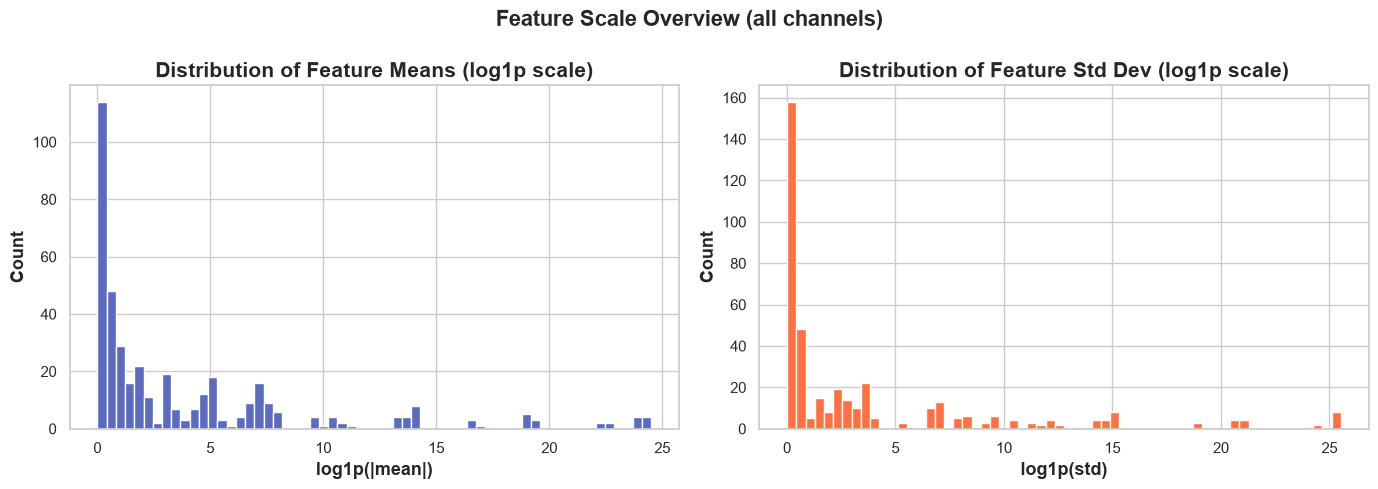

In [78]:
# Distribution of stds across all features: are scales wildly different?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_all = pd.Series([
    df[c].mean() for c in float_cols
    if df[c].mean() is not None
], name="mean")

stds_all = pd.Series([
    df[c].std() for c in float_cols
    if df[c].std() is not None
], name="std")

axes[0].hist(np.log1p(means_all.abs().clip(lower=0)), bins=60, color="#5C6BC0", edgecolor="white")
axes[0].set_title("Distribution of Feature Means (log1p scale)")
axes[0].set_xlabel("log1p(|mean|)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(stds_all.clip(lower=0)), bins=60, color="#FF7043", edgecolor="white")
axes[1].set_title("Distribution of Feature Std Dev (log1p scale)")
axes[1].set_xlabel("log1p(std)")
axes[1].set_ylabel("Count")

fig.suptitle("Feature Scale Overview (all channels)")
plt.tight_layout()
save_fig(fig, OUT_DIR, "02_feature_scales")
plt.show()

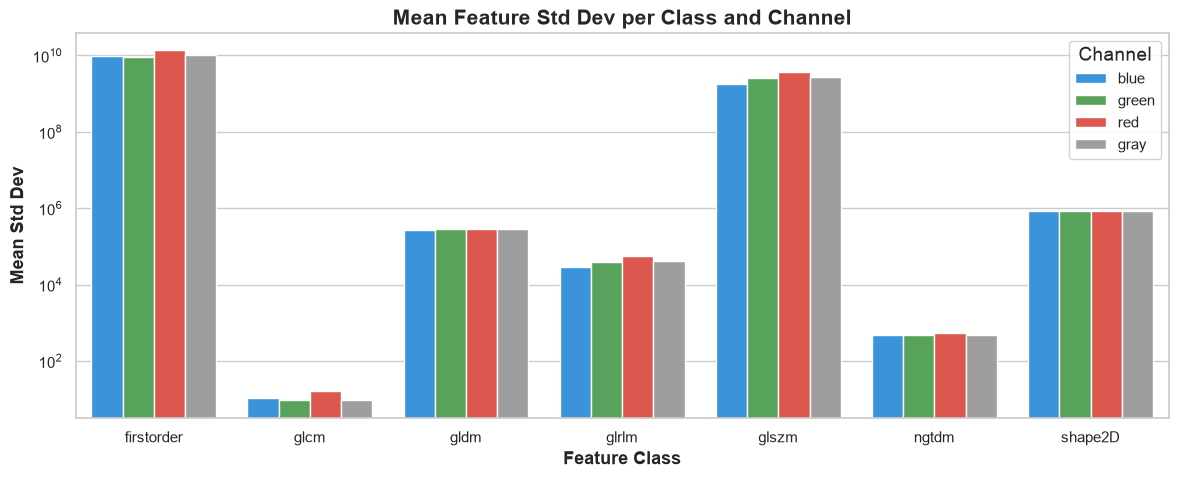

In [79]:
# Boxplot: mean std per feature class, colored by channel
box_data = []
for ch in CHANNELS:
    for fc in FEATURE_CLASSES:
        cols = [c for c in float_cols if c.startswith(f"{ch}__") and f"original_{fc}_" in c]
        if cols:
            std_mean = float(np.nanmean([df[c].std() for c in cols if df[c].std() is not None]))
            box_data.append({"channel": ch, "class": fc, "mean_std": std_mean})

box_df = pd.DataFrame(box_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=box_df, x="class", y="mean_std", hue="channel",
            palette=CHANNEL_COLORS, ax=ax)
ax.set_title("Mean Feature Std Dev per Class and Channel")
ax.set_xlabel("Feature Class")
ax.set_ylabel("Mean Std Dev")
ax.set_yscale("log")
ax.legend(title="Channel")
plt.tight_layout()
save_fig(fig, OUT_DIR, "03_std_by_class_channel")
plt.show()

---
## 5. Individual Feature Distributions

Representative feature per class across all 4 channels + normality test.

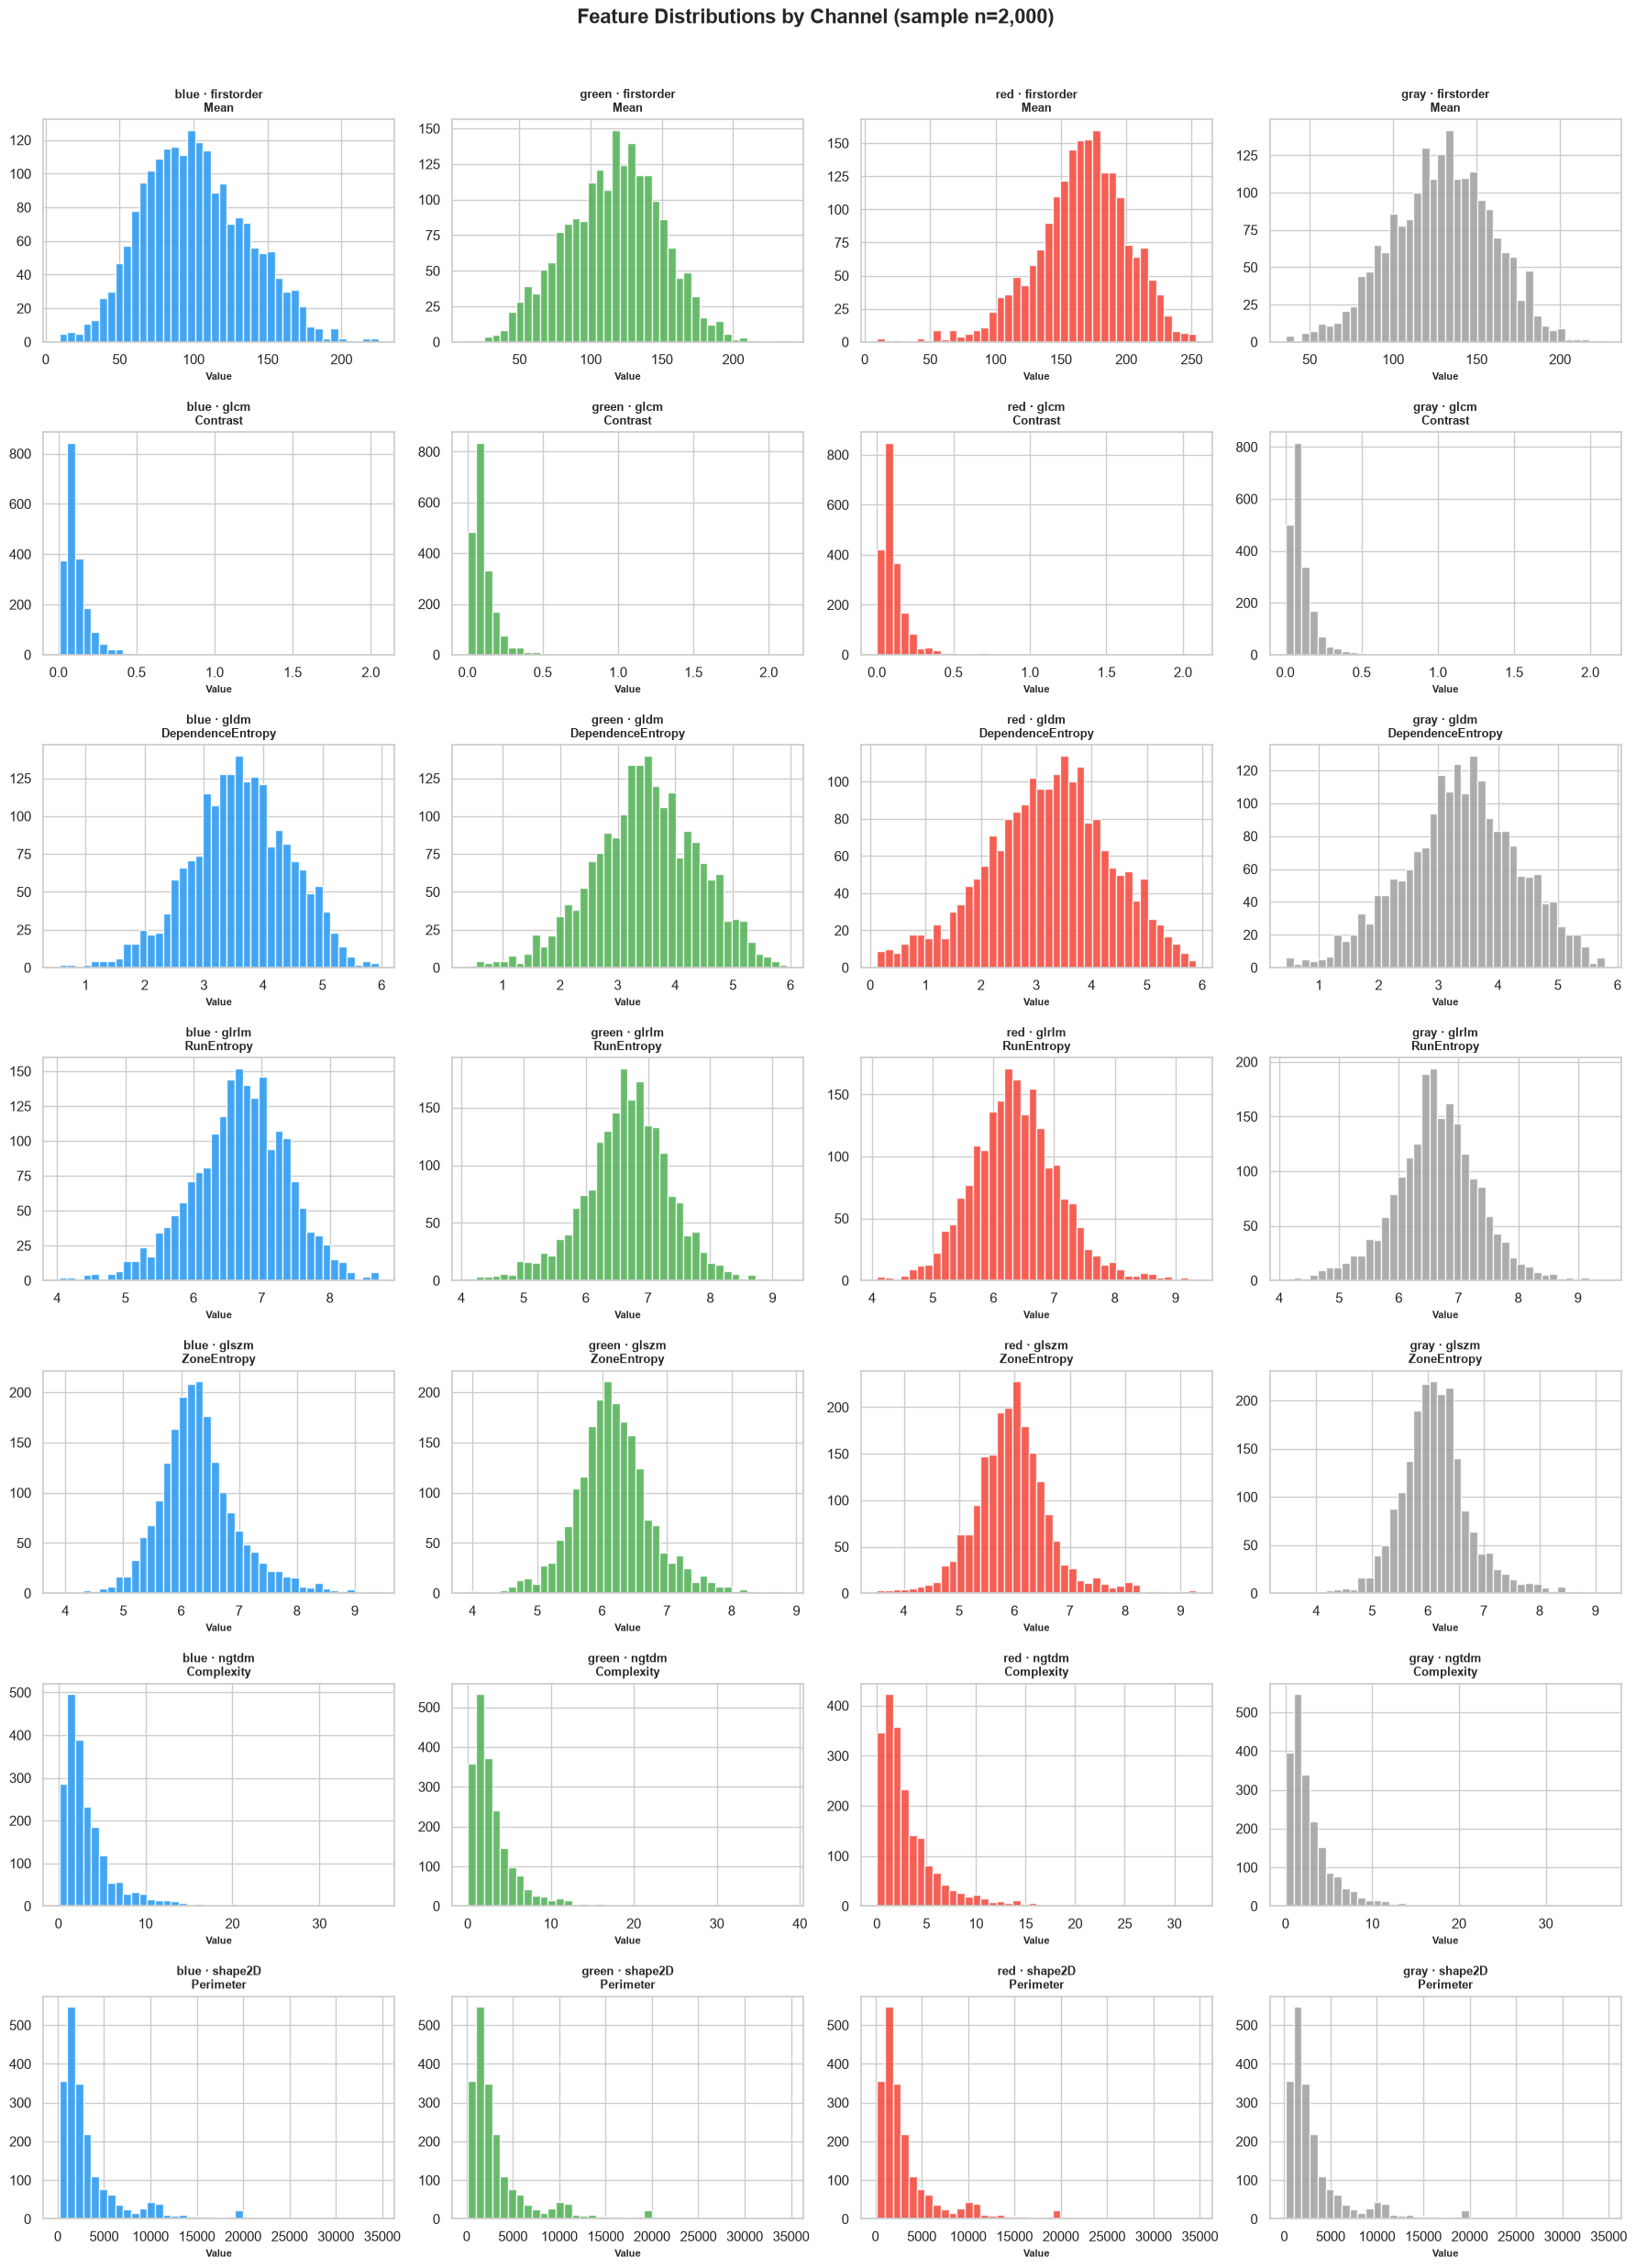


Normally distributed (KS p>0.05): 7 / 28


In [80]:
REPRESENTATIVE = {
    "firstorder": "Mean",
    "glcm":       "Contrast",
    "gldm":       "DependenceEntropy",
    "glrlm":      "RunEntropy",
    "glszm":      "ZoneEntropy",
    "ngtdm":      "Complexity",
    "shape2D":    "Perimeter",
}

sample_n = min(2000, n_rows)
df_sample = df.sample(sample_n, seed=42).to_pandas()

normality_rows = []

fig, axes = plt.subplots(len(REPRESENTATIVE), 4, figsize=(18, 3.5 * len(REPRESENTATIVE)))

for row_idx, (fc, feat) in enumerate(REPRESENTATIVE.items()):
    for col_idx, ch in enumerate(CHANNELS):
        col_name = f"{ch}__original_{fc}_{feat}"
        ax = axes[row_idx, col_idx]

        if col_name not in df_sample.columns:
            ax.set_visible(False)
            continue

        vals = df_sample[col_name].dropna().replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) < 10:
            ax.set_visible(False)
            continue

        ax.hist(vals, bins=40, color=CHANNEL_COLORS[ch], edgecolor="white", alpha=0.85)
        ax.set_title(f"{ch} · {fc}\n{feat}", fontsize=9)
        ax.set_xlabel("Value", fontsize=8)

        z = (vals - vals.mean()) / (vals.std() or 1)
        ks_stat, ks_p = stats.kstest(z, "norm")
        normality_rows.append({
            "channel": ch, "class": fc, "feature": feat,
            "ks_stat": round(ks_stat, 4), "ks_p": round(ks_p, 4),
            "normal": ks_p > 0.05
        })

fig.suptitle("Feature Distributions by Channel (sample n=2,000)", y=1.01)
plt.tight_layout()
save_fig(fig, OUT_DIR, "04_feature_distributions")
plt.show()

normality_df = pd.DataFrame(normality_rows)
print(f"\nNormally distributed (KS p>0.05): {normality_df['normal'].sum()} / {len(normality_df)}")

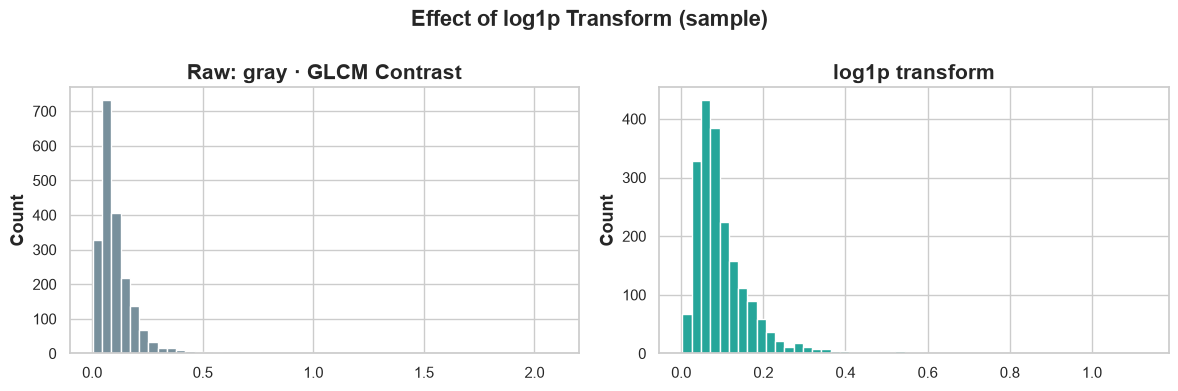

In [81]:
# Raw vs log-transform comparison for a heavily skewed feature
target_col = f"gray__original_glcm_Contrast"
if target_col in df_sample.columns:
    vals = df_sample[target_col].dropna().replace([np.inf, -np.inf], np.nan).dropna()
    vals_log = np.log1p(vals.clip(lower=0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(vals, bins=50, color="#78909C", edgecolor="white")
    axes[0].set_title("Raw: gray · GLCM Contrast")
    axes[1].hist(vals_log, bins=50, color="#26A69A", edgecolor="white")
    axes[1].set_title("log1p transform")
    for ax in axes:
        ax.set_ylabel("Count")
    fig.suptitle("Effect of log1p Transform (sample)")
    plt.tight_layout()
    save_fig(fig, OUT_DIR, "05_log_transform_example")
    plt.show()

---
## 6. Outlier Analysis

In [82]:
outlier_rows = []

for c in float_cols:
    col_data = df[c].drop_nulls().to_numpy()
    col_data = col_data[np.isfinite(col_data)]
    if len(col_data) < 10:
        continue
    q1, q3 = np.percentile(col_data, [25, 75])
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rate = float(np.mean((col_data < lo) | (col_data > hi)))
    parsed = parse_col(c)
    outlier_rows.append({"column": c, "channel": parsed["channel"],
                         "class": parsed["class"], "outlier_rate": rate})

outlier_df = pd.DataFrame(outlier_rows)
print(f"Mean outlier rate across all features: {outlier_df['outlier_rate'].mean():.2%}")
print(f"Features with >10% outliers: {(outlier_df['outlier_rate'] > 0.10).sum()}")

Mean outlier rate across all features: 6.38%
Features with >10% outliers: 101


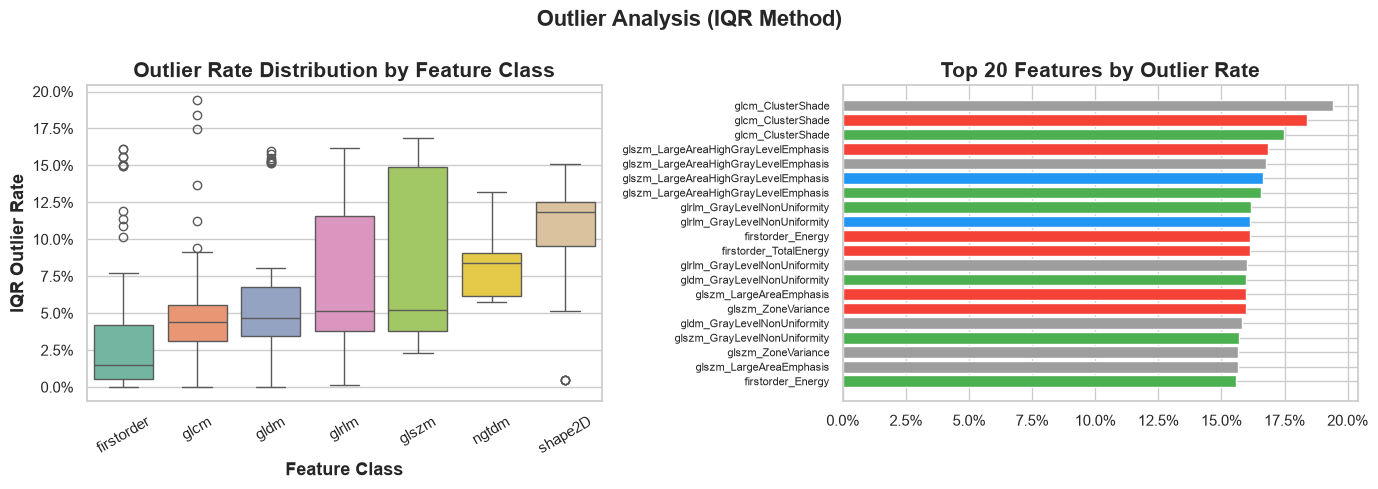

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outlier rate distribution per class
sns.boxplot(data=outlier_df, x="class", y="outlier_rate", ax=axes[0],
            palette="Set2", order=FEATURE_CLASSES)
axes[0].set_title("Outlier Rate Distribution by Feature Class")
axes[0].set_xlabel("Feature Class")
axes[0].set_ylabel("IQR Outlier Rate")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Top 20 most problematic features
top20 = outlier_df.nlargest(20, "outlier_rate")
short_names = top20["column"].str.replace(r".*__original_", "", regex=True)
axes[1].barh(range(20), top20["outlier_rate"].values,
             color=[CHANNEL_COLORS[c] for c in top20["channel"]])
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(short_names, fontsize=8)
axes[1].set_title("Top 20 Features by Outlier Rate")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].invert_yaxis()

fig.suptitle("Outlier Analysis (IQR Method)")
plt.tight_layout()
save_fig(fig, OUT_DIR, "06_outlier_analysis")
plt.show()

---
## 7. Inter-channel Redundancy

Are the 4 channels capturing distinct information, or are they highly correlated?

In [84]:
# For each feature, compute Pearson r between channels
# Use a sample to keep it fast
df_pd = df.select(float_cols).sample(min(5000, n_rows), seed=42).to_pandas()

# Get unique feature names (channel-independent)
unique_features = taxonomy[taxonomy["channel"] == "blue"][["class", "feature"]].copy()
unique_features["feat_id"] = unique_features["class"] + "_" + unique_features["feature"]

channel_pairs = [("blue", "green"), ("blue", "red"), ("blue", "gray"),
                 ("green", "red"), ("green", "gray"), ("red", "gray")]

corr_pair_data = {pair: [] for pair in channel_pairs}

for _, row in unique_features.iterrows():
    fc, feat = row["class"], row["feature"]
    for ch_a, ch_b in channel_pairs:
        col_a = f"{ch_a}__original_{fc}_{feat}"
        col_b = f"{ch_b}__original_{fc}_{feat}"
        if col_a in df_pd.columns and col_b in df_pd.columns:
            a = df_pd[col_a].replace([np.inf, -np.inf], np.nan).dropna()
            b = df_pd[col_b].replace([np.inf, -np.inf], np.nan).dropna()
            idx = a.index.intersection(b.index)
            if len(idx) > 50:
                r = np.corrcoef(a.loc[idx], b.loc[idx])[0, 1]
                if np.isfinite(r):
                    corr_pair_data[(ch_a, ch_b)].append(r)

pair_means = {f"{a}-{b}": np.mean(v) for (a, b), v in corr_pair_data.items() if v}
print("Mean Pearson r between channels (per feature):")
for pair, r in sorted(pair_means.items(), key=lambda x: -x[1]):
    print(f"  {pair:15s}: r = {r:.4f}")

Mean Pearson r between channels (per feature):
  green-gray     : r = 0.9289
  blue-green     : r = 0.8597
  red-gray       : r = 0.8449
  blue-gray      : r = 0.8414
  green-red      : r = 0.7804
  blue-red       : r = 0.6858


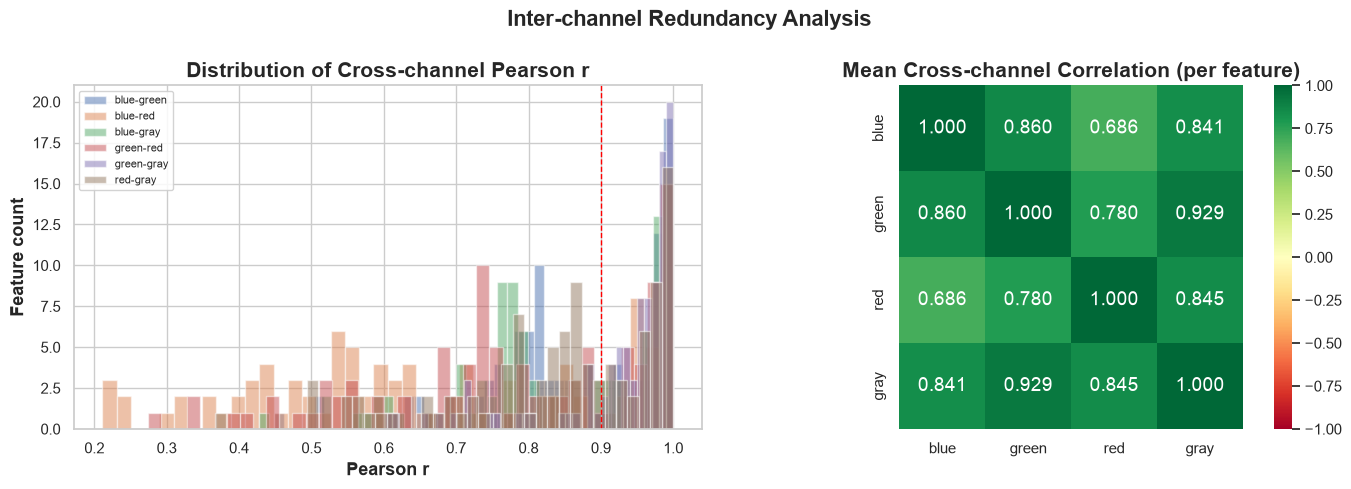

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of cross-channel correlations
for (ch_a, ch_b), corrs in corr_pair_data.items():
    if corrs:
        axes[0].hist(corrs, bins=40, alpha=0.5, label=f"{ch_a}-{ch_b}")
axes[0].set_title("Distribution of Cross-channel Pearson r")
axes[0].set_xlabel("Pearson r")
axes[0].set_ylabel("Feature count")
axes[0].legend(fontsize=8)
axes[0].axvline(0.9, color="red", linestyle="--", linewidth=1, label="r=0.9")

# 4x4 heatmap of mean cross-channel correlations
corr_matrix = pd.DataFrame(index=CHANNELS, columns=CHANNELS, dtype=float)
for i in range(len(CHANNELS)):
    corr_matrix.iloc[i, i] = 1.0
for (ch_a, ch_b), corrs in corr_pair_data.items():
    if corrs:
        m = float(np.mean(corrs))
        corr_matrix.loc[ch_a, ch_b] = m
        corr_matrix.loc[ch_b, ch_a] = m

sns.heatmap(corr_matrix.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title("Mean Cross-channel Correlation (per feature)")

fig.suptitle("Inter-channel Redundancy Analysis")
plt.tight_layout()
save_fig(fig, OUT_DIR, "07_interchannel_redundancy")
plt.show()

---
## 8. Intra-class Redundancy

Within each feature class, how many features are highly correlated (|r| > 0.95)?

In [86]:
redundancy_rows = []

for fc in FEATURE_CLASSES:
    cols = [c for c in float_cols if f"gray__original_{fc}_" in c]
    if len(cols) < 2:
        continue
    chunk = df_pd[cols].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")
    if chunk.shape[1] < 2:
        continue
    corr_mat = chunk.corr().abs()
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    n_pairs  = upper.count().sum()
    n_high   = (upper > 0.95).sum().sum()
    redundancy_rows.append({
        "class": fc, "n_features": len(cols),
        "n_pairs": int(n_pairs), "n_highly_corr": int(n_high),
        "redundancy_pct": round(n_high / n_pairs * 100, 1) if n_pairs > 0 else 0
    })

redundancy_df = pd.DataFrame(redundancy_rows).set_index("class")
redundancy_df

,n_features,n_pairs,n_highly_corr,redundancy_pct
class,,,,
firstorder,18,153,9,5.9
glcm,24,276,15,5.4
gldm,14,91,3,3.3
glrlm,16,120,2,1.7
glszm,16,120,2,1.7
ngtdm,5,10,0,0.0
shape2D,9,36,7,19.4


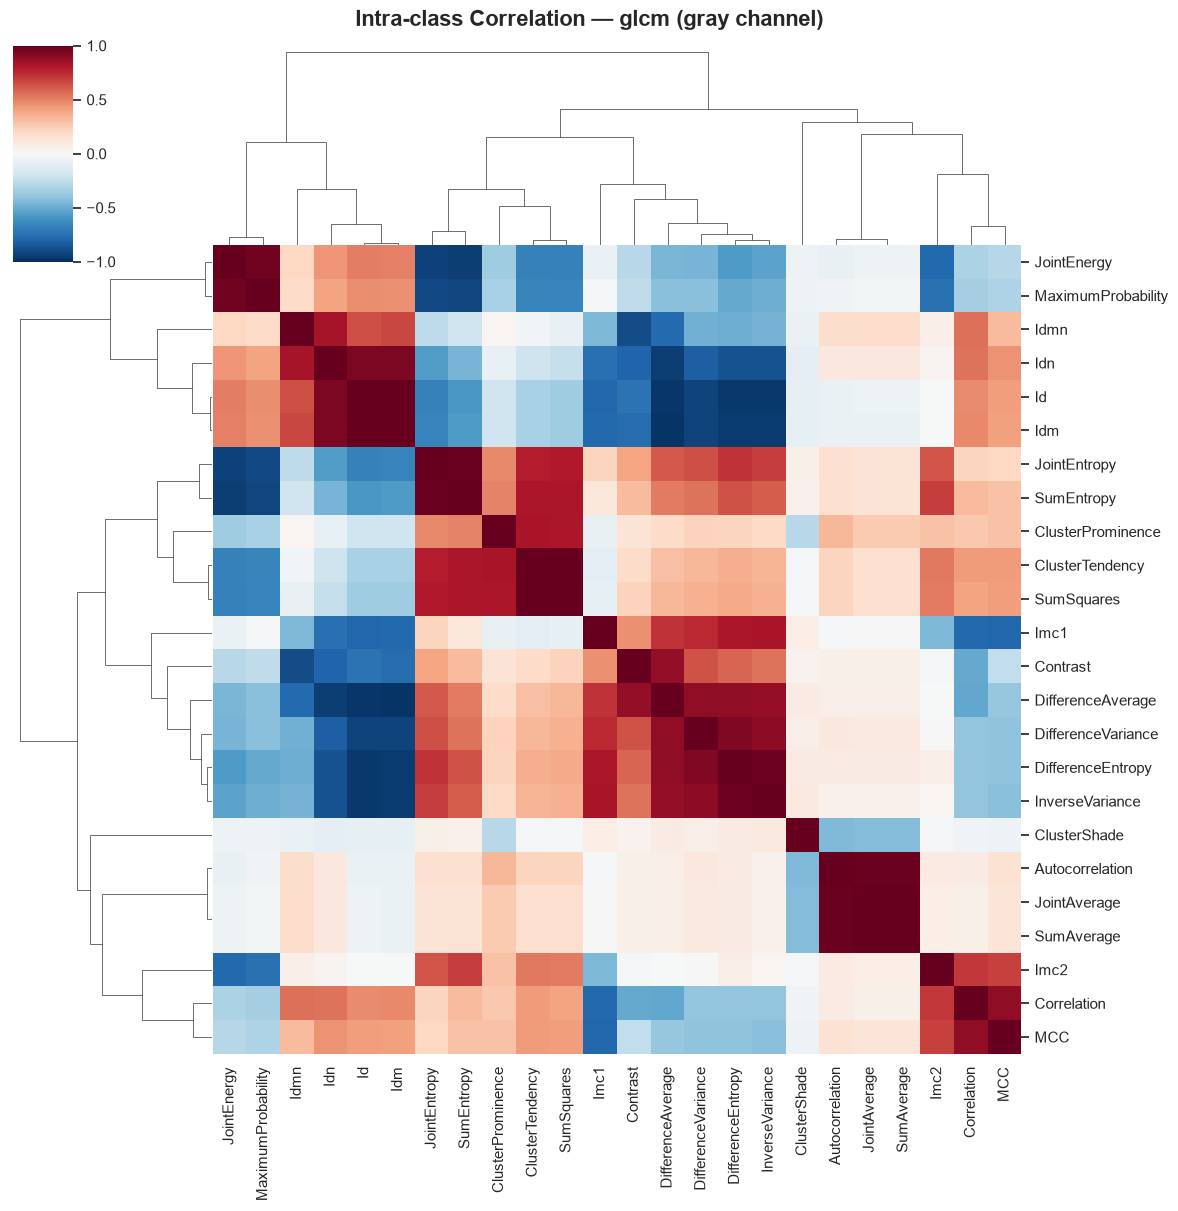

In [87]:
# Clustermap for the most feature-rich class (usually glcm)
dense_class = redundancy_df["n_features"].idxmax()
dense_cols  = [c for c in float_cols if f"gray__original_{dense_class}_" in c]
chunk = df_pd[dense_cols].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")

short_labels = [c.replace(f"gray__original_{dense_class}_", "") for c in chunk.columns]
chunk.columns = short_labels

g = sns.clustermap(chunk.corr(), cmap="RdBu_r", vmin=-1, vmax=1,
                   figsize=(12, 12), annot=False, linewidths=0)
g.fig.suptitle(f"Intra-class Correlation — {dense_class} (gray channel)", y=1.01)
save_fig(g.fig, OUT_DIR, f"08_intraclass_corr_{dense_class}")
plt.show()

---
## 9. Feature Space Structure — PCA

In [88]:
# Use gray channel only for PCA (one channel to avoid artificial inflation)
gray_cols = [c for c in float_cols if c.startswith("gray__")]

pca_sample = df.select(gray_cols).sample(min(5000, n_rows), seed=42).to_pandas()
pca_sample = pca_sample.replace([np.inf, -np.inf], np.nan)
pca_sample = pca_sample.fillna(pca_sample.median())
pca_sample = pca_sample.loc[:, pca_sample.std() > 0]  # drop zero-var

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_sample)

pca = PCA(n_components=min(100, X_scaled.shape[1]), random_state=42)
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n80 = int(np.searchsorted(cum_var, 0.80)) + 1
n90 = int(np.searchsorted(cum_var, 0.90)) + 1
n95 = int(np.searchsorted(cum_var, 0.95)) + 1

print(f"Gray channel features used : {pca_sample.shape[1]}")
print(f"Components for 80% variance: {n80}")
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")

Gray channel features used : 102
Components for 80% variance: 7
Components for 90% variance: 13
Components for 95% variance: 19


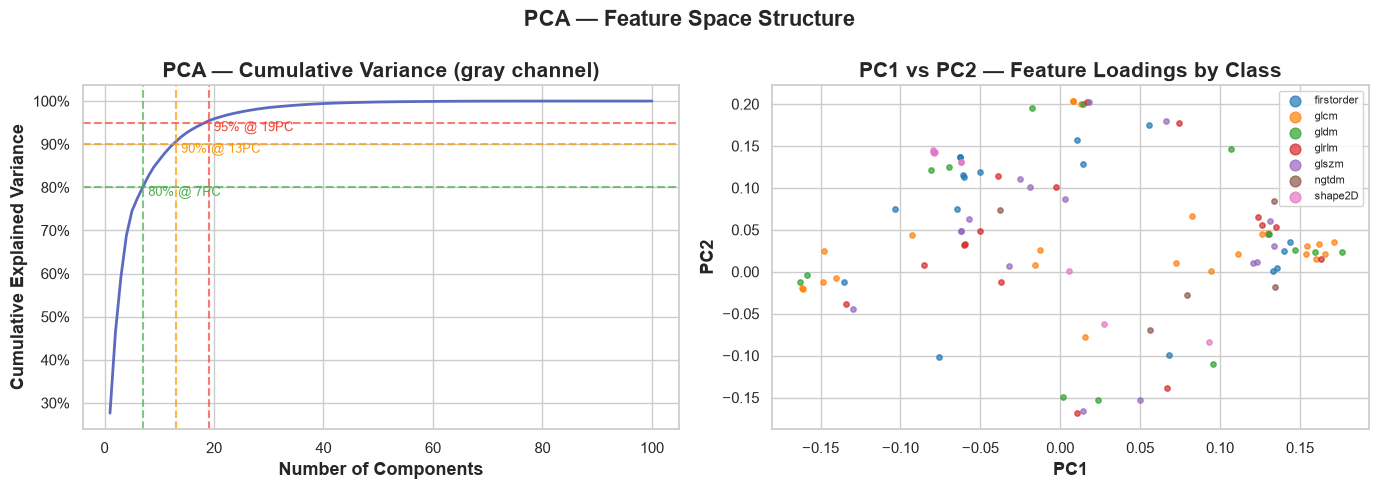

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
axes[0].plot(range(1, len(cum_var) + 1), cum_var, color="#5C6BC0", linewidth=2)
for thr, n, col in [(0.80, n80, "#4CAF50"), (0.90, n90, "#FF9800"), (0.95, n95, "#F44336")]:
    axes[0].axhline(thr, linestyle="--", color=col, alpha=0.7)
    axes[0].axvline(n,   linestyle="--", color=col, alpha=0.7)
    axes[0].text(n + 1, thr - 0.02, f"{int(thr*100)}% @ {n}PC", color=col, fontsize=9)
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA — Cumulative Variance (gray channel)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# PC1 vs PC2 — colored by feature class (loadings)
loadings = pd.DataFrame(pca.components_[:2].T, columns=["PC1", "PC2"],
                        index=pca_sample.columns)
loadings["class"] = loadings.index.str.replace(r"gray__original_(\w+)_.*", r"\1", regex=True)
palette = dict(zip(FEATURE_CLASSES, sns.color_palette("tab10", len(FEATURE_CLASSES))))

for fc, grp in loadings.groupby("class"):
    axes[1].scatter(grp["PC1"], grp["PC2"], label=fc, s=15,
                    color=palette.get(fc, "gray"), alpha=0.7)
axes[1].set_title("PC1 vs PC2 — Feature Loadings by Class")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8, markerscale=2)

fig.suptitle("PCA — Feature Space Structure")
plt.tight_layout()
save_fig(fig, OUT_DIR, "09_pca")
plt.show()

---
## 10. Integration with ISIC Labels

Join with diagnosis metadata and assess class separability.

In [90]:
if not METADATA_PATH.exists():
    print(f"Metadata not found at {METADATA_PATH}. Skipping label integration.")
    labeled_df = None
    label_col  = None
else:
    meta = pd.read_parquet(METADATA_PATH)
    print(f"Metadata shape  : {meta.shape}")
    print(f"Metadata columns:\n  {list(meta.columns)}")

    # Candidate label columns — extend this list based on the output above
    LABEL_CANDIDATES = [
        "benign_malignant", "diagnosis", "dx", "category",
        "target", "label", "class", "lesion_type",
    ]
    label_col = next((c for c in LABEL_CANDIDATES if c in meta.columns), None)

    if label_col is None:
        print("\n⚠ No label column found. Set LABEL_COL manually:")
        print("    label_col = '<column_name_from_the_list_above>'")
        labeled_df = None
    else:
        print(f"\nUsing label column: '{label_col}'")
        print(f"Value counts:\n{meta[label_col].value_counts()}")

        id_col_meta = "isic_id" if "isic_id" in meta.columns else meta.columns[0]
        df_pd_full  = df.to_pandas()
        id_col_name = "image_id" if "image_id" in df_pd_full.columns else df_pd_full.columns[0]

        labeled_df = df_pd_full.merge(
            meta[[id_col_meta, label_col]].rename(columns={id_col_meta: id_col_name}),
            on=id_col_name,
            how="inner",
        )
        print(f"\nMatched rows: {len(labeled_df):,} / {len(df_pd_full):,}")

Metadata shape  : (76974, 14)
Metadata columns:
  ['isic_id', 'lesion_id', 'patient_id', 'age_approx', 'anatom_site_Anogenital region', 'anatom_site_Head and neck', 'anatom_site_Lower extremity', 'anatom_site_Trunk', 'anatom_site_Upper extremity', 'anatom_site_unknown', 'pixels_x', 'pixels_y', 'sex', 'target']

Using label column: 'target'
Value counts:
target
Benign-melanocytic           48974
Malignant-melanocytic        10669
Benign-non-melanocytic        9585
Malignant-non-melanocytic     7746
Name: count, dtype: int64

Matched rows: 76,715 / 76,715


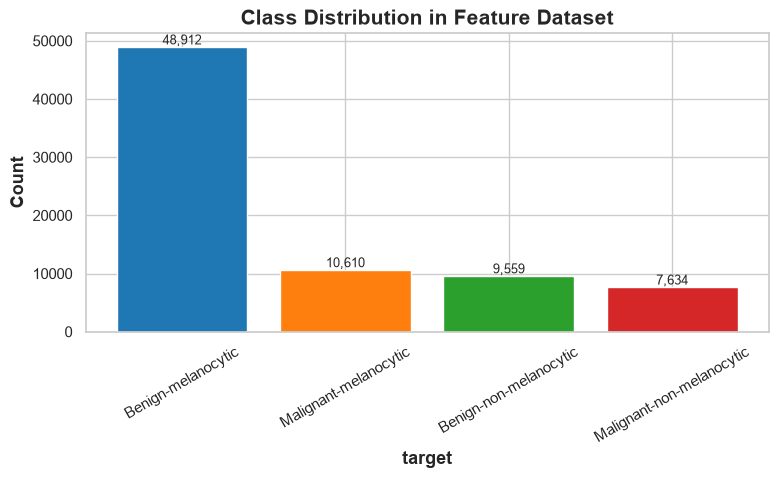

In [91]:
if labeled_df is not None and label_col:
    classes = labeled_df[label_col].unique()
    n_cls   = len(classes)

    # Class distribution
    fig, ax = plt.subplots(figsize=(max(8, n_cls * 1.5), 5))
    vc = labeled_df[label_col].value_counts()
    palette_cls = dict(zip(vc.index, sns.color_palette("tab10", len(vc))))
    bars = ax.bar(vc.index, vc.values, color=[palette_cls[c] for c in vc.index])
    ax.set_title("Class Distribution in Feature Dataset")
    ax.set_xlabel(label_col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f"{val:,}",
                ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    save_fig(fig, OUT_DIR, "10_class_distribution")
    plt.show()

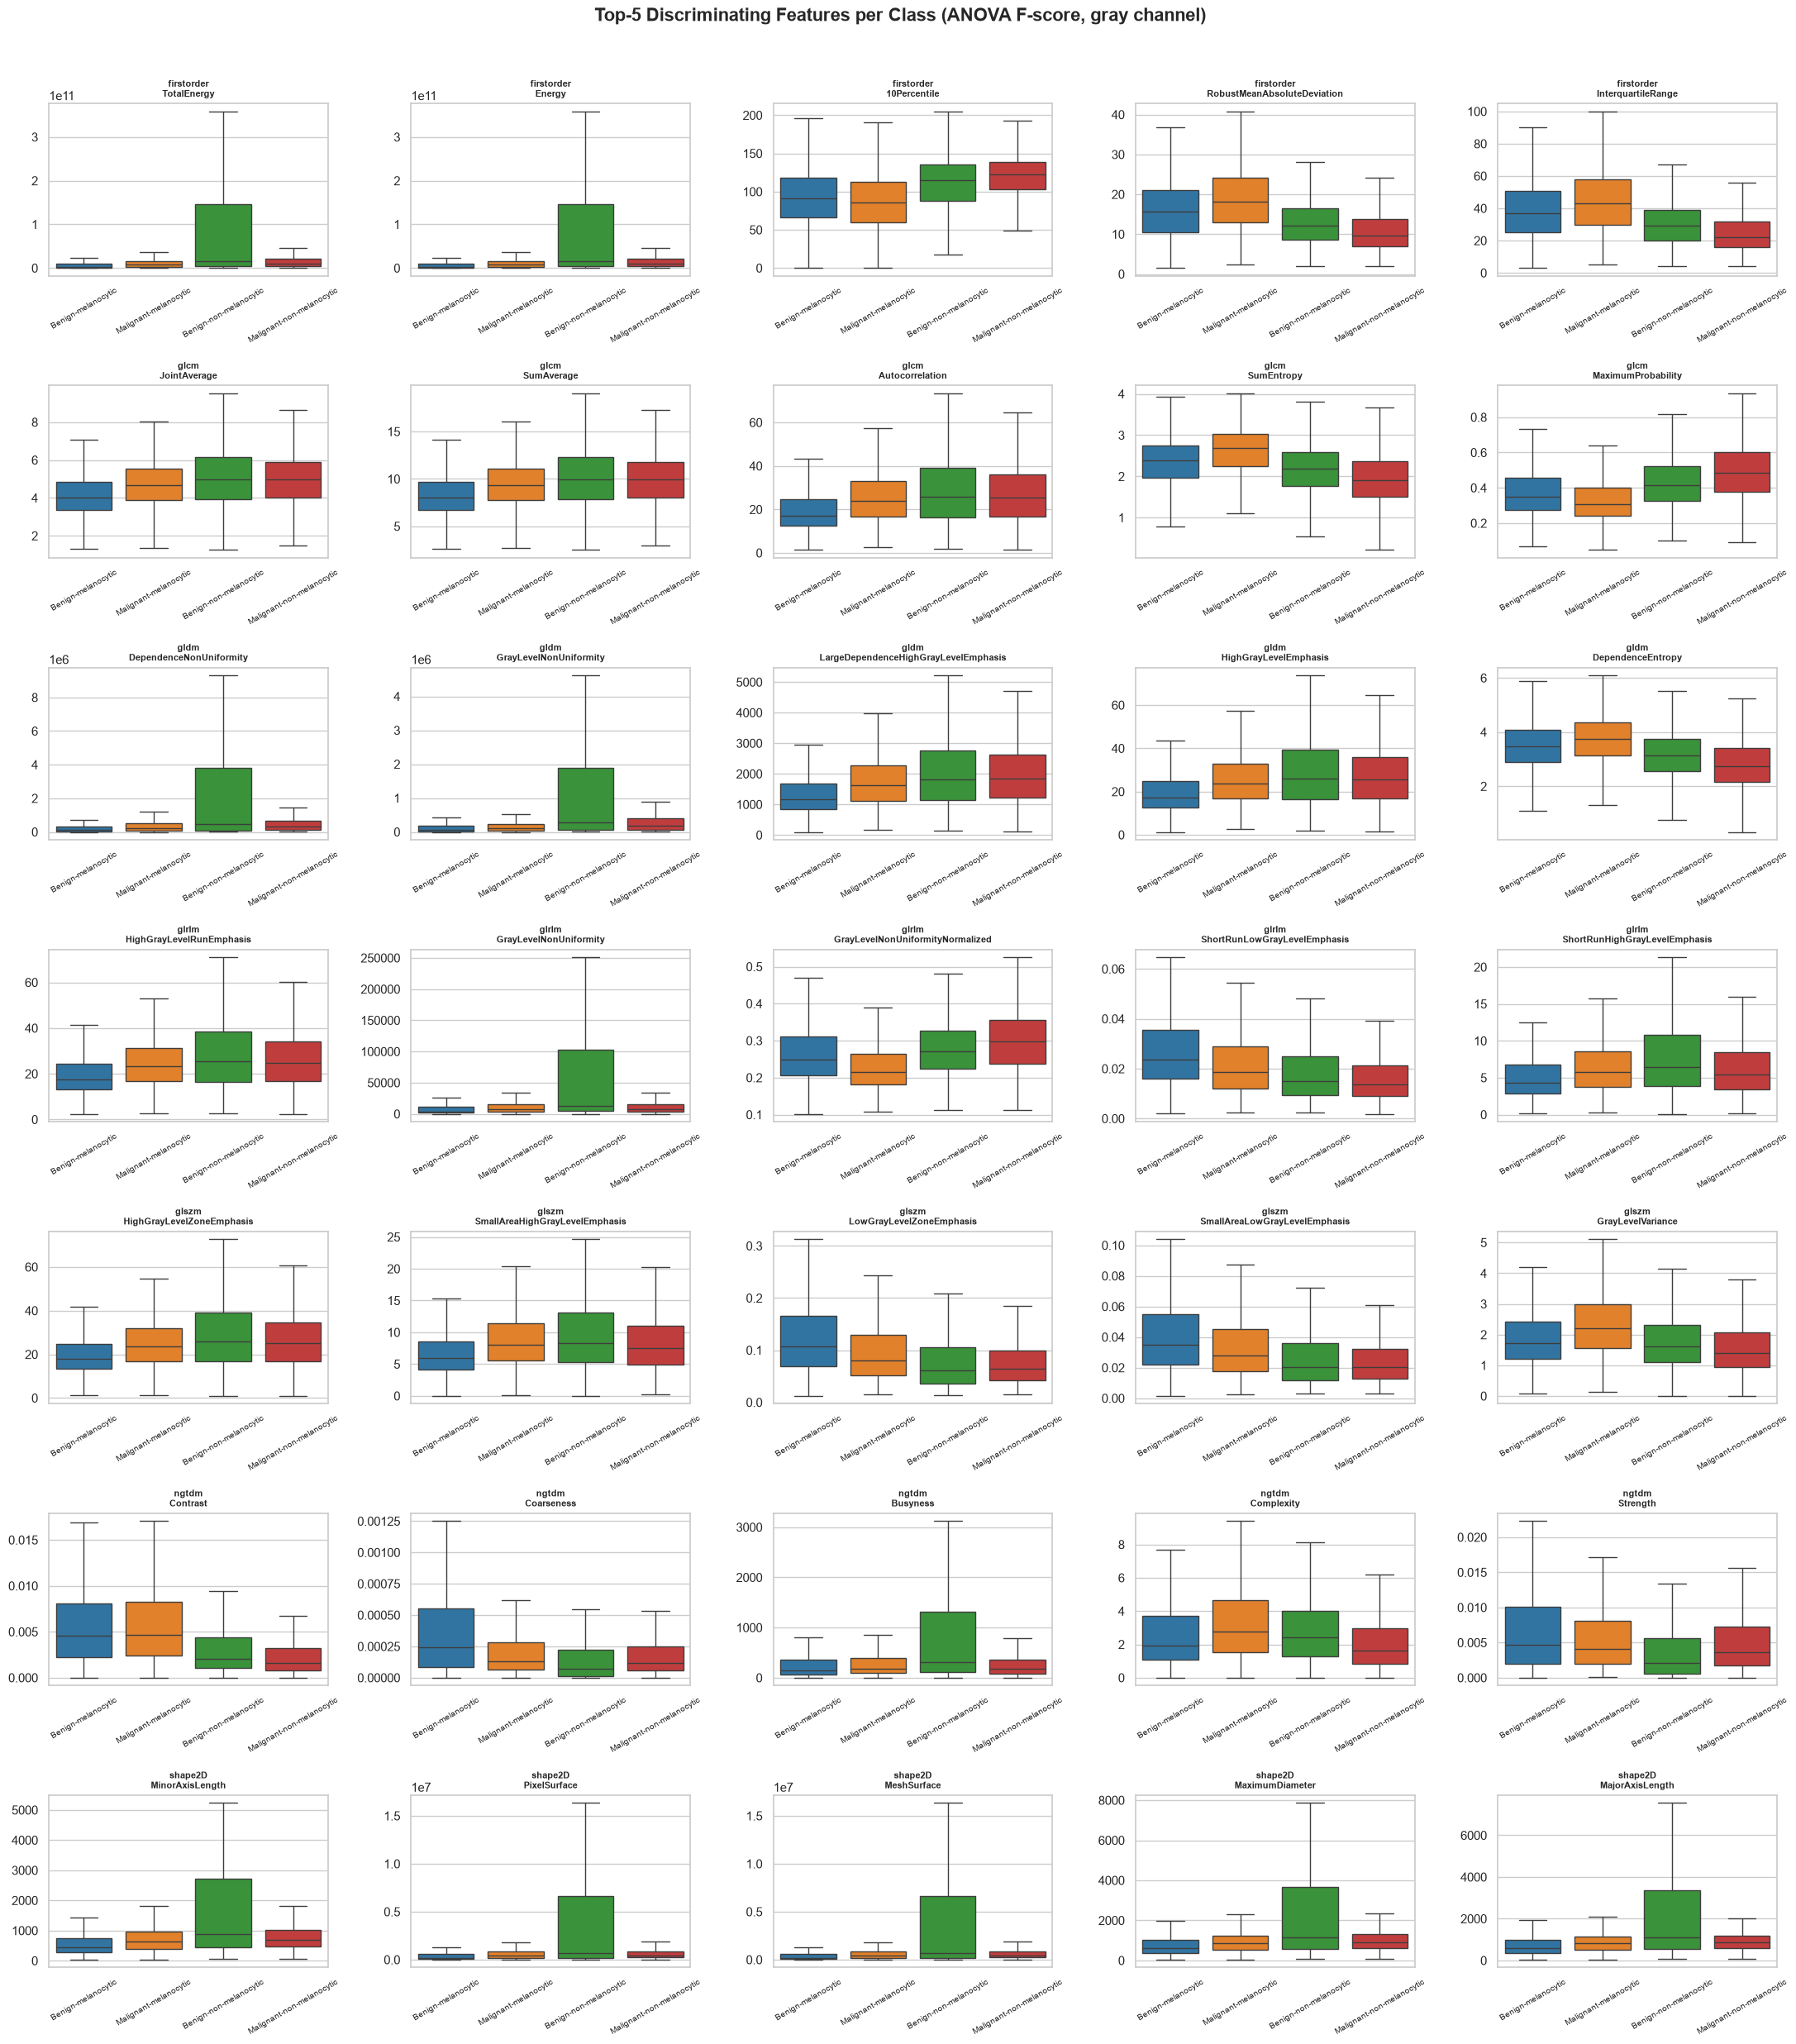

In [92]:
if labeled_df is not None and label_col:
    # Top-5 discriminating features per class using ANOVA F-score
    y = labeled_df[label_col]
    top_features_by_class = {}

    fig, axes = plt.subplots(len(FEATURE_CLASSES), 5,
                             figsize=(22, 3.5 * len(FEATURE_CLASSES)))

    for row_idx, fc in enumerate(FEATURE_CLASSES):
        fc_cols = [c for c in float_cols if f"gray__original_{fc}_" in c
                   and c in labeled_df.columns]
        if len(fc_cols) < 2:
            for col_idx in range(5):
                axes[row_idx, col_idx].set_visible(False)
            continue

        X_fc = labeled_df[fc_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        f_scores, _ = f_classif(X_fc, y)
        top5_idx = np.argsort(f_scores)[::-1][:5]
        top5_cols = [fc_cols[i] for i in top5_idx]
        top_features_by_class[fc] = top5_cols

        for col_idx, col in enumerate(top5_cols):
            ax = axes[row_idx, col_idx]
            feat_label = col.replace(f"gray__original_{fc}_", "")
            sns.boxplot(data=labeled_df, x=label_col, y=col, ax=ax,
                        palette=palette_cls, showfliers=False)
            ax.set_title(f"{fc}\n{feat_label}", fontsize=8)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis="x", rotation=30, labelsize=7)

    fig.suptitle("Top-5 Discriminating Features per Class (ANOVA F-score, gray channel)", y=1.01)
    plt.tight_layout()
    save_fig(fig, OUT_DIR, "11_discriminating_features")
    plt.show()

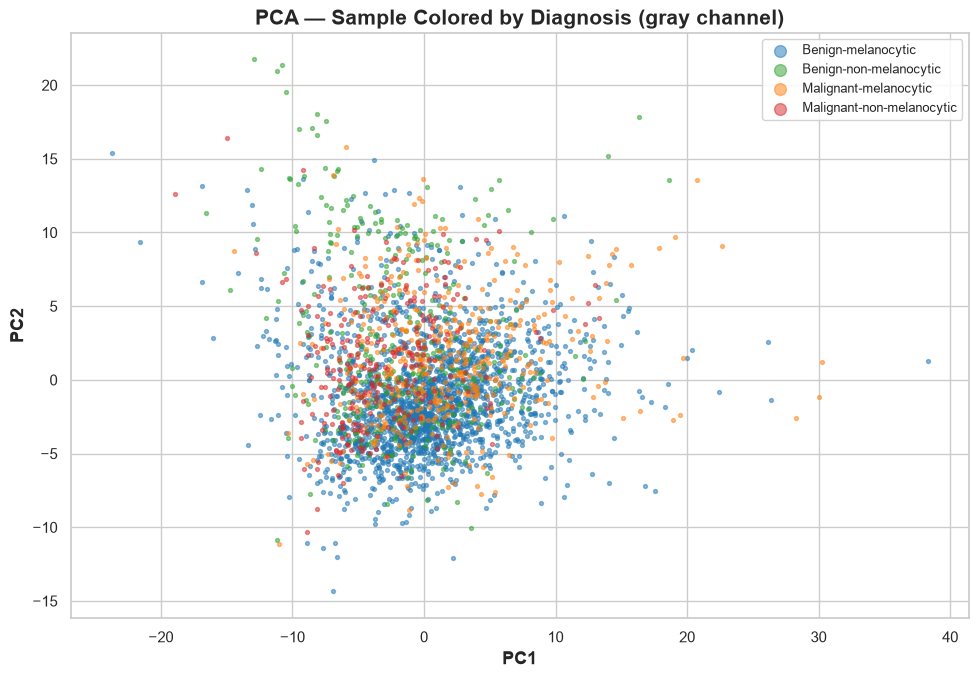

In [93]:
if labeled_df is not None and label_col:
    # PCA colored by diagnosis
    pca_labeled = labeled_df[gray_cols].replace([np.inf, -np.inf], np.nan)
    pca_labeled = pca_labeled.fillna(pca_labeled.median())
    pca_labeled = pca_labeled.loc[:, pca_labeled.std() > 0]

    sample_idx = pca_labeled.sample(min(3000, len(pca_labeled)), random_state=42).index
    X_pca = scaler.fit_transform(pca_labeled.loc[sample_idx])
    coords = PCA(n_components=2, random_state=42).fit_transform(X_pca)
    labels_sample = labeled_df.loc[sample_idx, label_col]

    fig, ax = plt.subplots(figsize=(10, 7))
    for cls in sorted(labels_sample.unique()):
        mask = labels_sample == cls
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=cls, s=8, alpha=0.5, color=palette_cls.get(cls, "gray"))
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("PCA — Sample Colored by Diagnosis (gray channel)")
    ax.legend(markerscale=3, fontsize=9)
    plt.tight_layout()
    save_fig(fig, OUT_DIR, "12_pca_by_diagnosis")
    plt.show()

---
## 11. Summary & Recommendations

Decision table for the ML preprocessing pipeline.

In [94]:
total_features  = len(float_cols)
redundant_total = redundancy_df["n_highly_corr"].sum()
mean_outlier    = outlier_df["outlier_rate"].mean()

recommendations = pd.DataFrame([
    {
        "Aspect":         "Null values",
        "Finding":        f"{cols_any_null} columns affected ({cols_any_null/total_features:.1%})",
        "Recommendation": "Impute with column median",
    },
    {
        "Aspect":         "Infinite values",
        "Finding":        f"{cols_with_inf} columns affected (shape2D most common)",
        "Recommendation": "Replace ±inf → NaN → impute median",
    },
    {
        "Aspect":         "Zero-variance features",
        "Finding":        f"{len(zero_var_cols)} columns",
        "Recommendation": "Drop before any model",
    },
    {
        "Aspect":         "Intra-class redundancy",
        "Finding":        f"{redundant_total} feature pairs with |r| > 0.95",
        "Recommendation": "Apply correlation filter (threshold 0.95)",
    },
    {
        "Aspect":         "Inter-channel redundancy",
        "Finding":        f"Mean r blue-green = {pair_means.get('blue-green', float('nan')):.3f}",
        "Recommendation": "Evaluate dropping one of {blue, green}; keep red + gray",
    },
    {
        "Aspect":         "Outliers",
        "Finding":        f"Mean IQR outlier rate = {mean_outlier:.2%}",
        "Recommendation": "Winsorize at p1–p99 per feature",
    },
    {
        "Aspect":         "Scale",
        "Finding":        "Features span multiple orders of magnitude",
        "Recommendation": "StandardScaler mandatory before any distance-based model",
    },
    {
        "Aspect":         "Effective dimensionality",
        "Finding":        f"PCA 95% variance = {n95} components (gray channel)",
        "Recommendation": f"True rank ~{n95} — feature selection can be aggressive",
    },
])

recommendations

,Aspect,Finding,Recommendation
0,Null values,0 columns affected (0.0%),Impute with column median
1,Infinite values,0 columns affected (shape2D most common),Replace ±inf → NaN → impute median
2,Zero-variance features,0 columns,Drop before any model
3,Intra-class redundancy,38 feature pairs with |r| > 0.95,Apply correlation filter (threshold 0.95)
4,Inter-channel redundancy,Mean r blue-green = 0.860,"Evaluate dropping one of {blue, green}; keep r..."
5,Outliers,Mean IQR outlier rate = 6.38%,Winsorize at p1–p99 per feature
6,Scale,Features span multiple orders of magnitude,StandardScaler mandatory before any distance-b...
7,Effective dimensionality,PCA 95% variance = 19 components (gray channel),True rank ~19 — feature selection can be aggre...


In [95]:
print("=" * 60)
print("EDA COMPLETE")
print(f"  Dataset       : {n_rows:,} images × {total_features:,} features")
print(f"  Channels      : {len(CHANNELS)} (blue, green, red, gray)")
print(f"  Feature classes: {len(FEATURE_CLASSES)}")
print(f"  Plots saved to: {OUT_DIR}")
print("=" * 60)

EDA COMPLETE
  Dataset       : 76,715 images × 408 features
  Channels      : 4 (blue, green, red, gray)
  Feature classes: 7
  Plots saved to: /Users/indalecio.rios/Documents/personal-github/scd-ml/results/eda/features
